# Congressional Stock Trading Performance Analysis

Analysis of Cumulative Abnormal Returns (CAR) for congressional trades using CAPM-adjusted beta

In [11]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## Load Data

In [12]:
# Load the stock performance analysis data
df = pl.read_parquet('../data/trades/stock_performance_analysis.parquet')

print(f"Total trades: {df.height}")
print(f"\nColumns: {df.columns}")
print(f"\nShape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Total trades: 37273

Columns: ['Ticker', 'TickerType', 'Company', 'Traded', 'Transaction', 'Trade_Size_USD', 'Status', 'Subholding', 'Description', 'Name', 'BioGuideID', 'Filed', 'Party', 'District', 'Chamber', 'Comments', 'Quiver_Upload_Time', 'excess_return', 'State', 'last_modified', 'TradeDate', 'beta', 'car_traded_to_filed', 'car_filed_to_1m', 'car_filed_to_3m', 'car_filed_to_6m', 'car_filed_to_9m', 'car_filed_to_12m']

Shape: (37273, 28)

First few rows:


Ticker,TickerType,Company,Traded,Transaction,Trade_Size_USD,Status,Subholding,Description,Name,BioGuideID,Filed,Party,District,Chamber,Comments,Quiver_Upload_Time,excess_return,State,last_modified,TradeDate,beta,car_traded_to_filed,car_filed_to_1m,car_filed_to_3m,car_filed_to_6m,car_filed_to_9m,car_filed_to_12m
str,str,null,date,str,str,null,null,str,str,str,date,str,str,str,null,null,str,null,str,date,f64,f64,f64,f64,f64,f64,f64
"""0QZI.IL""","""Stock""",null,2019-09-25,"""Purchase""","""1001.0""",null,null,null,"""Jerry Moran""","""M000934""",2019-10-21,"""R""",null,"""Senate""",null,null,null,null,"""2023-08-28""",2019-09-25,0.727671,0.048328,0.043696,0.105955,-0.022874,0.227017,0.346748
"""0QZI.IL""","""Stock""",null,2019-09-25,"""Purchase""","""1001.0""",null,null,null,"""Jerry Moran""","""M000934""",2019-10-21,"""R""",null,"""Senate""",null,null,null,null,"""2023-08-28""",2019-09-25,0.727671,0.048328,0.043696,0.105955,-0.022874,0.227017,0.346748
"""A""","""ST""",null,2025-07-16,"""Sale""","""1001.0""",null,null,null,"""Lisa Mcclain""","""M001136""",2025-08-13,"""R""",""" MI09""","""Representatives""",null,null,"""1.65044220600913""",null,"""2025-08-14""",2025-07-16,1.018688,0.008713,0.021594,0.181618,0.0203,0.0203,0.0203
"""A""","""ST""",null,2025-06-17,"""Purchase""","""1001.0""",null,null,null,"""Lisa Mcclain""","""M001136""",2025-08-13,"""R""",""" MI09""","""Representatives""",null,null,"""-5.74204882405014""",null,"""2025-08-14""",2025-06-17,1.00133,-0.029838,0.021907,0.182353,0.021317,0.021317,0.021317
"""A""","""ST""",null,2025-05-15,"""Purchase""","""1001.0""",null,null,null,"""Rob Bresnahan""","""B001327""",2025-05-31,"""R""",""" PA08""","""Representatives""",null,null,"""-3.56980035348525""",null,"""2025-06-02""",2025-05-15,0.994056,-0.007426,0.018153,0.051284,0.203491,0.013727,0.013727


## Data Quality Summary

In [13]:
# Check null values and success rates
total = df.height

null_counts = {
    'beta': df['beta'].null_count(),
    'car_traded_to_filed': df['car_traded_to_filed'].null_count(),
    'car_filed_to_1m': df['car_filed_to_1m'].null_count(),
    'car_filed_to_3m': df['car_filed_to_3m'].null_count(),
    'car_filed_to_6m': df['car_filed_to_6m'].null_count(),
    'car_filed_to_9m': df['car_filed_to_9m'].null_count(),
    'car_filed_to_12m': df['car_filed_to_12m'].null_count(),
}

print("NULL Value Counts and Success Rates:")
print("="*60)
for col, nulls in null_counts.items():
    success_pct = ((total - nulls) / total) * 100
    print(f"{col:25s}: {nulls:5d} nulls ({100-success_pct:.1f}%) | Success: {success_pct:.1f}%")

print(f"\nOverall success rate: {((total - null_counts['car_filed_to_12m']) / total) * 100:.1f}%")

NULL Value Counts and Success Rates:
beta                     :   518 nulls (1.4%) | Success: 98.6%
car_traded_to_filed      :  1093 nulls (2.9%) | Success: 97.1%
car_filed_to_1m          :   549 nulls (1.5%) | Success: 98.5%
car_filed_to_3m          :   549 nulls (1.5%) | Success: 98.5%
car_filed_to_6m          :   549 nulls (1.5%) | Success: 98.5%
car_filed_to_9m          :   549 nulls (1.5%) | Success: 98.5%
car_filed_to_12m         :   549 nulls (1.5%) | Success: 98.5%

Overall success rate: 98.5%


## Beta Distribution

Beta Statistics (n=36755):
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ value         │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 36755.0       │
│ null_count ┆ 0.0           │
│ mean       ┆ NaN           │
│ std        ┆ NaN           │
│ min        ┆ -15598.392139 │
│ 25%        ┆ 0.762117      │
│ 50%        ┆ 0.997872      │
│ 75%        ┆ 1.230835      │
│ max        ┆ 3.881778      │
└────────────┴───────────────┘


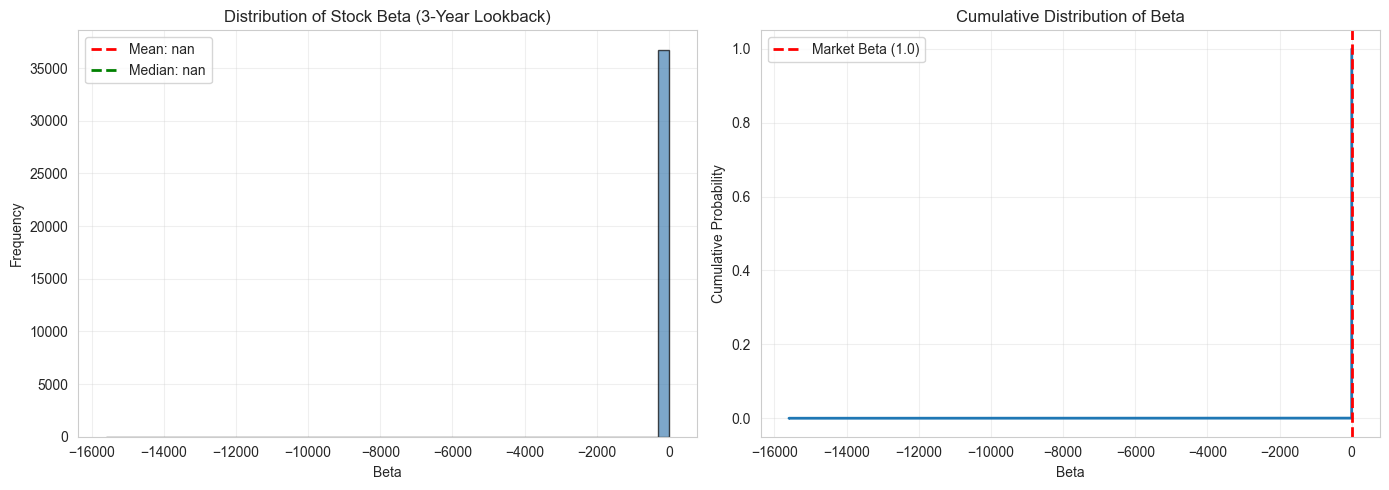


Beta Classification:
  High Beta (>1.2):         10335 (28.1%)
  Neutral Beta (0.8-1.2):   15941 (43.4%)
  Low Beta (<0.8):          10472 (28.5%)


In [14]:
# Analyze beta values (3-year lookback)
beta_data = df.filter(pl.col('beta').is_not_null())

print(f"Beta Statistics (n={beta_data.height}):")
print(beta_data['beta'].describe())

# Plot beta distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

beta_values = beta_data['beta'].to_numpy()

axes[0].hist(beta_values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(beta_values), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(beta_values):.2f}')
axes[0].axvline(np.median(beta_values), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(beta_values):.2f}')
axes[0].set_xlabel('Beta')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Stock Beta (3-Year Lookback)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative distribution
sorted_beta = np.sort(beta_values)
axes[1].plot(sorted_beta, np.arange(1, len(sorted_beta)+1) / len(sorted_beta), linewidth=2)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Market Beta (1.0)')
axes[1].set_xlabel('Beta')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Cumulative Distribution of Beta')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Count stocks by beta type
high_beta = (beta_values > 1.2).sum()
low_beta = (beta_values < 0.8).sum()
neutral_beta = ((beta_values >= 0.8) & (beta_values <= 1.2)).sum()

print(f"\nBeta Classification:")
print(f"  High Beta (>1.2):        {high_beta:6d} ({high_beta/len(beta_values)*100:.1f}%)")
print(f"  Neutral Beta (0.8-1.2):  {neutral_beta:6d} ({neutral_beta/len(beta_values)*100:.1f}%)")
print(f"  Low Beta (<0.8):         {low_beta:6d} ({low_beta/len(beta_values)*100:.1f}%)")

## CAR Distribution by Time Window

In [15]:
# Analyze CAR by time period
car_columns = ['car_traded_to_filed', 'car_filed_to_1m', 'car_filed_to_3m', 
               'car_filed_to_6m', 'car_filed_to_9m', 'car_filed_to_12m']

car_stats = {}
for col in car_columns:
    valid_data = df.filter(pl.col(col).is_not_null())[col].to_numpy()
    car_stats[col] = {
        'mean': np.mean(valid_data),
        'median': np.median(valid_data),
        'std': np.std(valid_data),
        'min': np.min(valid_data),
        'max': np.max(valid_data),
        'count': len(valid_data)
    }

print("CAR Statistics by Time Window:")
print("="*80)
for period in car_columns:
    stats = car_stats[period]
    print(f"\n{period}:")
    print(f"  Count:  {stats['count']:6d}")
    print(f"  Mean:   {stats['mean']:8.4f}")
    print(f"  Median: {stats['median']:8.4f}")
    print(f"  Std:    {stats['std']:8.4f}")
    print(f"  Min:    {stats['min']:8.4f}")
    print(f"  Max:    {stats['max']:8.4f}")

CAR Statistics by Time Window:

car_traded_to_filed:
  Count:   36180
  Mean:        nan
  Median:      nan
  Std:         nan
  Min:         nan
  Max:         nan

car_filed_to_1m:
  Count:   36724
  Mean:        nan
  Median:      nan
  Std:         nan
  Min:         nan
  Max:         nan

car_filed_to_3m:
  Count:   36724
  Mean:        nan
  Median:      nan
  Std:         nan
  Min:         nan
  Max:         nan

car_filed_to_6m:
  Count:   36724
  Mean:        nan
  Median:      nan
  Std:         nan
  Min:         nan
  Max:         nan

car_filed_to_9m:
  Count:   36724
  Mean:        nan
  Median:      nan
  Std:         nan
  Min:         nan
  Max:         nan

car_filed_to_12m:
  Count:   36724
  Mean:        nan
  Median:      nan
  Std:         nan
  Min:         nan
  Max:         nan


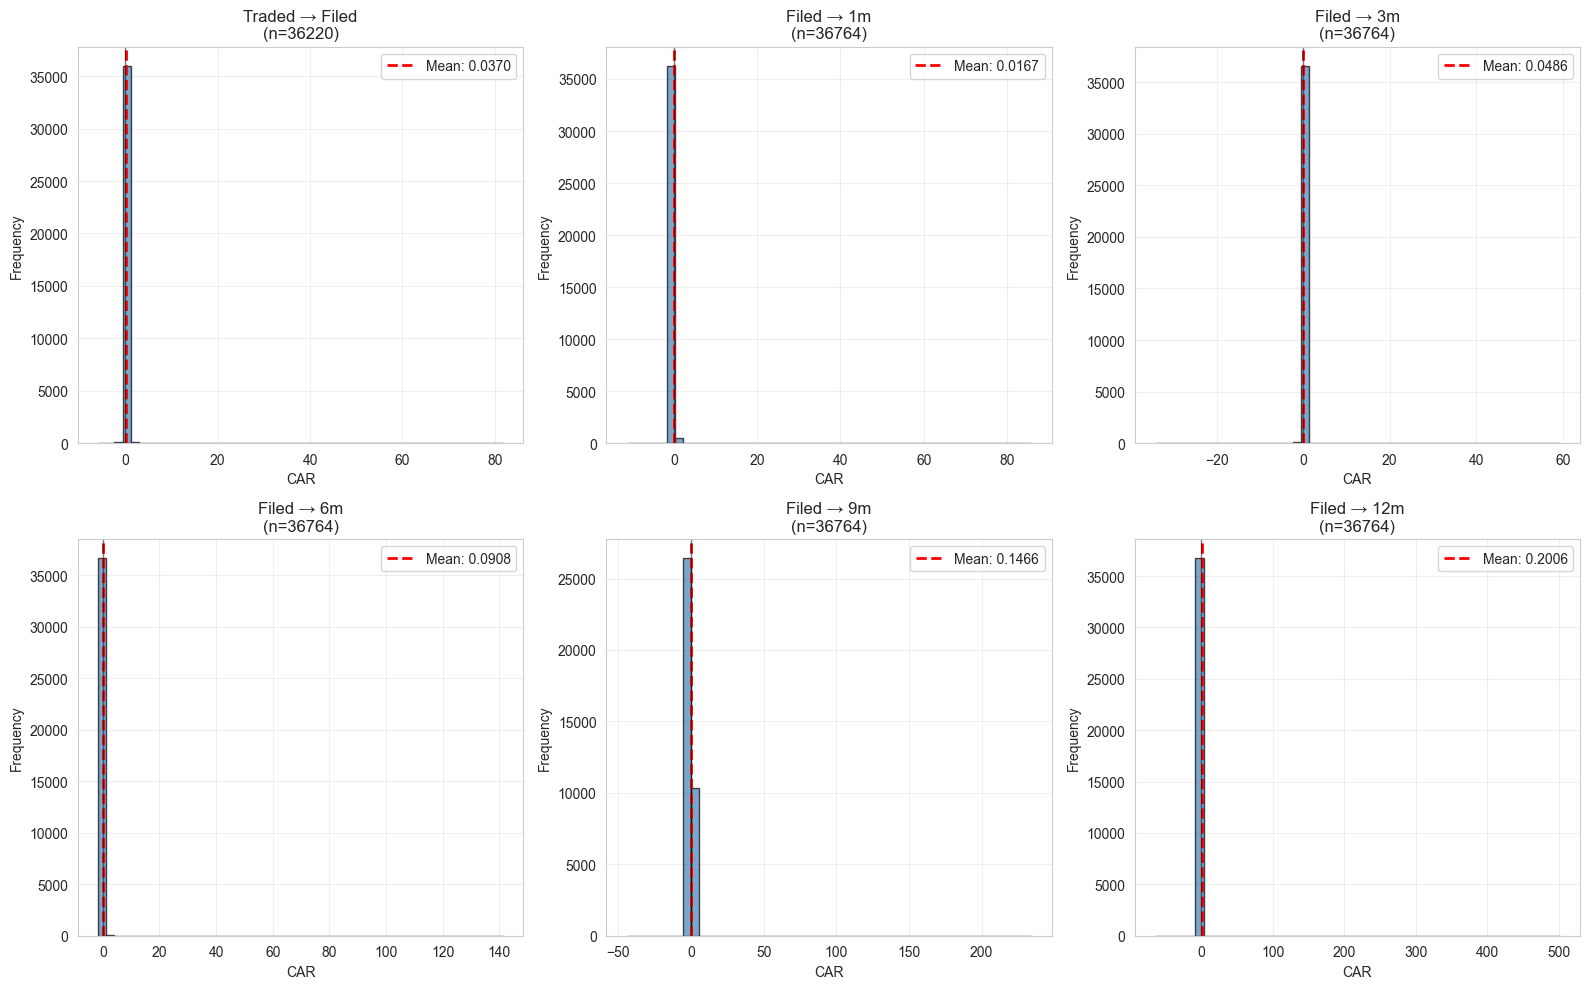

In [6]:
# Visualize CAR distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

period_labels = ['Traded → Filed', 'Filed → 1m', 'Filed → 3m', 
                 'Filed → 6m', 'Filed → 9m', 'Filed → 12m']

for idx, (col, label) in enumerate(zip(car_columns, period_labels)):
    valid_data = df.filter(pl.col(col).is_not_null())[col].to_numpy()
    
    axes[idx].hist(valid_data, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].axvline(np.mean(valid_data), color='red', linestyle='--', linewidth=2, 
                     label=f'Mean: {np.mean(valid_data):.4f}')
    axes[idx].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    axes[idx].set_xlabel('CAR')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{label}\n(n={len(valid_data)})')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Trading Performance: Positive vs Negative CAR

Positive vs Negative CAR:
Traded → Filed      :  18488 positive ( 51.1%) |  17691 negative
Filed → 1m          :  18651 positive ( 50.8%) |  18072 negative
Filed → 3m          :  19131 positive ( 52.1%) |  17592 negative
Filed → 6m          :  19506 positive ( 53.1%) |  17217 negative
Filed → 9m          :  19937 positive ( 54.3%) |  16786 negative
Filed → 12m         :  20211 positive ( 55.0%) |  16512 negative


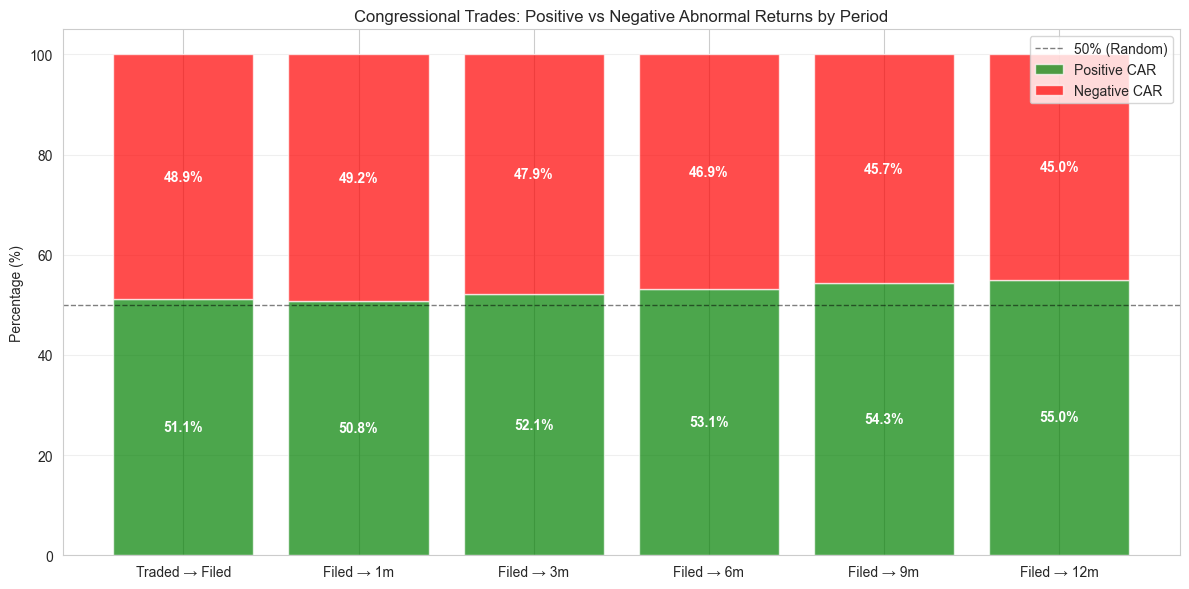

In [16]:
# Analyze positive vs negative CAR
performance = {}

for col in car_columns:
    valid_data = df.filter(pl.col(col).is_not_null())
    positive = (valid_data[col] > 0).sum()
    negative = (valid_data[col] < 0).sum()
    total = valid_data.height
    
    performance[col] = {
        'positive': positive,
        'negative': negative,
        'total': total,
        'positive_pct': (positive / total) * 100
    }

print("Positive vs Negative CAR:")
print("="*80)
for col, period_label in zip(car_columns, period_labels):
    stats = performance[col]
    print(f"{period_label:20s}: {stats['positive']:6d} positive ({stats['positive_pct']:5.1f}%) | {stats['negative']:6d} negative")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(period_labels))
positive_pcts = [performance[col]['positive_pct'] for col in car_columns]
negative_pcts = [100 - p for p in positive_pcts]

ax.bar(x_pos, positive_pcts, label='Positive CAR', color='green', alpha=0.7)
ax.bar(x_pos, negative_pcts, bottom=positive_pcts, label='Negative CAR', color='red', alpha=0.7)
ax.axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.5, label='50% (Random)')

ax.set_ylabel('Percentage (%)')
ax.set_title('Congressional Trades: Positive vs Negative Abnormal Returns by Period')
ax.set_xticks(x_pos)
ax.set_xticklabels(period_labels)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (pos, neg) in enumerate(zip(positive_pcts, negative_pcts)):
    ax.text(i, pos/2, f'{pos:.1f}%', ha='center', va='center', fontweight='bold', color='white')
    ax.text(i, pos + neg/2, f'{neg:.1f}%', ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## Best and Worst Performing Trades

In [17]:
# Get best and worst performers at 12-month window
df_valid = df.filter(pl.col('car_filed_to_12m').is_not_null()).sort('car_filed_to_12m', descending=True)

print("\nTOP 10 BEST PERFORMING TRADES (12-month CAR):")
print("="*100)
top_10 = df_valid.head(10).select(['Name', 'Ticker', 'Traded', 'car_filed_to_12m', 'beta']).to_pandas()
print(top_10.to_string(index=False))

print("\n\nTOP 10 WORST PERFORMING TRADES (12-month CAR):")
print("="*100)
worst_10 = df_valid.tail(10).sort('car_filed_to_12m').select(['Name', 'Ticker', 'Traded', 'car_filed_to_12m', 'beta']).to_pandas()
print(worst_10.to_string(index=False))


TOP 10 BEST PERFORMING TRADES (12-month CAR):
                    Name Ticker     Traded  car_filed_to_12m     beta
Donald Sternoff Beyer Jr  DAIUF 2020-02-19               NaN      NaN
Donald Sternoff Beyer Jr  DAIUF 2020-01-29               NaN      NaN
Donald Sternoff Beyer Jr  DAIUF 2019-12-24               NaN      NaN
Donald Sternoff Beyer Jr  DAIUF 2019-12-10               NaN      NaN
Donald Sternoff Beyer Jr  DAIUF 2019-11-27               NaN      NaN
Donald Sternoff Beyer Jr  DAIUF 2019-11-27               NaN      NaN
Donald Sternoff Beyer Jr  DAIUF 2019-11-19               NaN      NaN
              Rick Scott   VAXX 2023-12-20        501.504038 0.999277
              Rick Scott   VAXX 2023-12-20        501.504038 0.999277
              Rick Scott   VAXX 2023-12-20        501.504038 0.999277


TOP 10 WORST PERFORMING TRADES (12-month CAR):
                     Name Ticker     Traded  car_filed_to_12m     beta
                Ron Wyden   IRBT 2025-02-06         -2.234986 0

## By Politician Analysis

In [9]:
# Analyze by politician
df_valid = df.filter(pl.col('car_filed_to_12m').is_not_null())

politician_stats = df_valid.group_by('Name').agg([
    pl.count().alias('trade_count'),
    pl.col('car_filed_to_12m').mean().alias('avg_car_12m'),
    pl.col('car_filed_to_12m').std().alias('std_car_12m'),
    pl.col('car_filed_to_12m').max().alias('max_car_12m'),
    pl.col('car_filed_to_12m').min().alias('min_car_12m'),
]).sort('trade_count', descending=True)

print("\nTOP TRADERS (by trade count):")
print("="*100)
top_traders = politician_stats.head(15).to_pandas()
print(top_traders[['Name', 'trade_count', 'avg_car_12m', 'std_car_12m']].to_string(index=False))

# Best performers
best_traders = politician_stats.filter(pl.col('trade_count') >= 10).sort('avg_car_12m', descending=True)

print("\n\nBEST AVERAGE PERFORMERS (min 10 trades):")
print("="*100)
print(best_traders.head(10).to_pandas()[['Name', 'trade_count', 'avg_car_12m', 'std_car_12m']].to_string(index=False))


TOP TRADERS (by trade count):
             Name  trade_count  avg_car_12m  std_car_12m
  Josh Gottheimer         2915     0.179997     0.379381
 Gilbert Cisneros         1656     0.233962     0.395298
     David Perdue         1571     0.247263     0.366392
     Lisa Mcclain         1377     0.074346     0.247972
   Daniel Goldman         1069     0.121567     0.315261
        Susie Lee         1007     0.166014     0.363301
   Greg Gianforte          853     0.320936     5.594740
     Lois Frankel          826     0.144694     0.298308
Alan S. Lowenthal          760     0.216614     0.469320
 Tommy Tuberville          721     0.079656     0.313829
    Kathy Manning          716     0.098790     0.298452
    Dean Phillips          716     0.262910     0.331628
       Kevin Hern          607     0.127400     0.343871
    Rob Bresnahan          586     0.199924     0.409560
 Jefferson Shreve          549     0.196243     0.393827


BEST AVERAGE PERFORMERS (min 10 trades):
              

/var/folders/9w/kc7bcj2n1zb8vx5h3z6ld8s00000gn/T/ipykernel_93642/2969398065.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('trade_count'),


## Key Insights

In [10]:
# Calculate key statistics
df_valid = df.filter(pl.col('car_filed_to_12m').is_not_null())
car_12m = df_valid['car_filed_to_12m'].to_numpy()

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

print(f"\n1. DATA QUALITY:")
print(f"   - Total trades analyzed: {df.height:,}")
print(f"   - Successful CAR calculations: {df_valid.height:,} ({(df_valid.height/df.height)*100:.1f}%)")
print(f"   - Failed/incomplete: {df.height - df_valid.height:,} ({((df.height - df_valid.height)/df.height)*100:.1f}%)")

print(f"\n2. CONGRESSIONAL TRADING PERFORMANCE (12-month window):")
print(f"   - Average CAR: {np.mean(car_12m):+.4f}")
print(f"   - Median CAR:  {np.median(car_12m):+.4f}")
print(f"   - Std Dev:     {np.std(car_12m):.4f}")
print(f"   - Win Rate:    {(car_12m > 0).sum() / len(car_12m) * 100:.1f}%")

print(f"\n3. INTERPRETATION:")
if np.mean(car_12m) > 0.01:
    print(f"   ✓ Congress members outperformed market expectations on average")
elif np.mean(car_12m) < -0.01:
    print(f"   ✗ Congress members underperformed market expectations on average")
else:
    print(f"   ≈ Congress members performed in line with market expectations")

if (car_12m > 0).sum() / len(car_12m) > 0.55:
    print(f"   ✓ Win rate above 50% suggests positive selection ability")
elif (car_12m > 0).sum() / len(car_12m) < 0.45:
    print(f"   ✗ Win rate below 50% suggests negative selection ability")
else:
    print(f"   ≈ Win rate near 50% suggests no selection ability")


KEY INSIGHTS

1. DATA QUALITY:
   - Total trades analyzed: 37,273
   - Successful CAR calculations: 36,764 (98.6%)
   - Failed/incomplete: 509 (1.4%)

2. CONGRESSIONAL TRADING PERFORMANCE (12-month window):
   - Average CAR: +0.2006
   - Median CAR:  +0.1479
   - Std Dev:     4.6246
   - Win Rate:    71.9%

3. INTERPRETATION:
   ✓ Congress members outperformed market expectations on average
   ✓ Win rate above 50% suggests positive selection ability
